<a href="https://colab.research.google.com/github/sankeawthong/Project-1-Lita-Chatbot/blob/main/Lab04%20Decision%20Trees_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 — Grow, Draw, Prune, Interrogate

**Machine Learning · Week 4 · Decission Trees**

| | |
|---|---|
| **Time budget** | ~2 hours (in-lab) |
| **Learning objectives** | 1. Train and visualize decision trees; verify a split computation by hand — 2. Diagnose and control overfitting with pre- and post-pruning, tuned by CV — 3. Demonstrate tree instability and articulate its consequences — 4. Extract and critically interpret feature importances |
| **Dataset** | Breast Cancer Wisconsin (569 tumours, 30 features, benign/malignant) — real medical data, via scikit-learn |
| **Grading** | Exercises 1–5 + AI-usage disclosure · self-checks give instant feedback |

> **Today you look inside a model for the first time.** Every model so far has been a sealed box: K-NN points at neighbours, Naive Bayes multiplies odds you never see. A decision tree can be *drawn* — and once drawn, read, checked, and argued with. You'll also verify, by hand, that the machine's root split is exactly the arithmetic you did in Activity 1.

**First:** File → Save a copy in Drive, rename to `Lab4_<your_student_id>`.

---
## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

RNG_SEED = 42
np.random.seed(RNG_SEED)
print("Setup complete ✔")

Setup complete ✔


---
## Part 1 · Real medical data

569 tumour samples, 30 features computed from cell-nucleus images, one label: **malignant** or **benign**. A dataset where explanations genuinely matter — no oncologist acts on an unexplained score.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
print("shape:", X.shape)
print("classes:", dict(zip(data.target_names, np.bincount(y))))
print("first five features:", list(data.feature_names[:5]))

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RNG_SEED)
print("\ntrain:", Xtr.shape[0], "| test:", Xte.shape[0], "(locked away until the very end)")

shape: (569, 30)
classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
first five features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]

train: 426 | test: 143 (locked away until the very end)


Note what we are **not** doing: no `StandardScaler`. The lecture explained why — every tree question touches one feature alone, so scales never mix. One of Week 2's ceremonies, legitimately skipped. (The train/test split and its discipline, however, remain non-negotiable — that ceremony belongs to honesty, not to any particular model.)

---
## Part 2 · Grow a tree — and draw it

In [3]:
full_tree = DecisionTreeClassifier(random_state=RNG_SEED).fit(Xtr, ytr)

print(f"depth:            {full_tree.get_depth()}")
print(f"leaves:           {full_tree.get_n_leaves()}")
print(f"training accuracy: {full_tree.score(Xtr, ytr):.3f}")
cv_full = cross_val_score(DecisionTreeClassifier(random_state=RNG_SEED), Xtr, ytr, cv=5)
print(f"5-fold CV:         {cv_full.mean():.3f} ± {cv_full.std():.3f}")

depth:            7
leaves:           18
training accuracy: 1.000
5-fold CV:         0.930 ± 0.028


Training accuracy **1.000** — the tree memorized the training set, exactly as the lecture warned. The CV mean is the honest number, and the gap between them is overfitting, measured.

Now the moment: let's *look at it*. The full tree is too big to read, so we'll draw only its top 3 levels — the most important decisions.

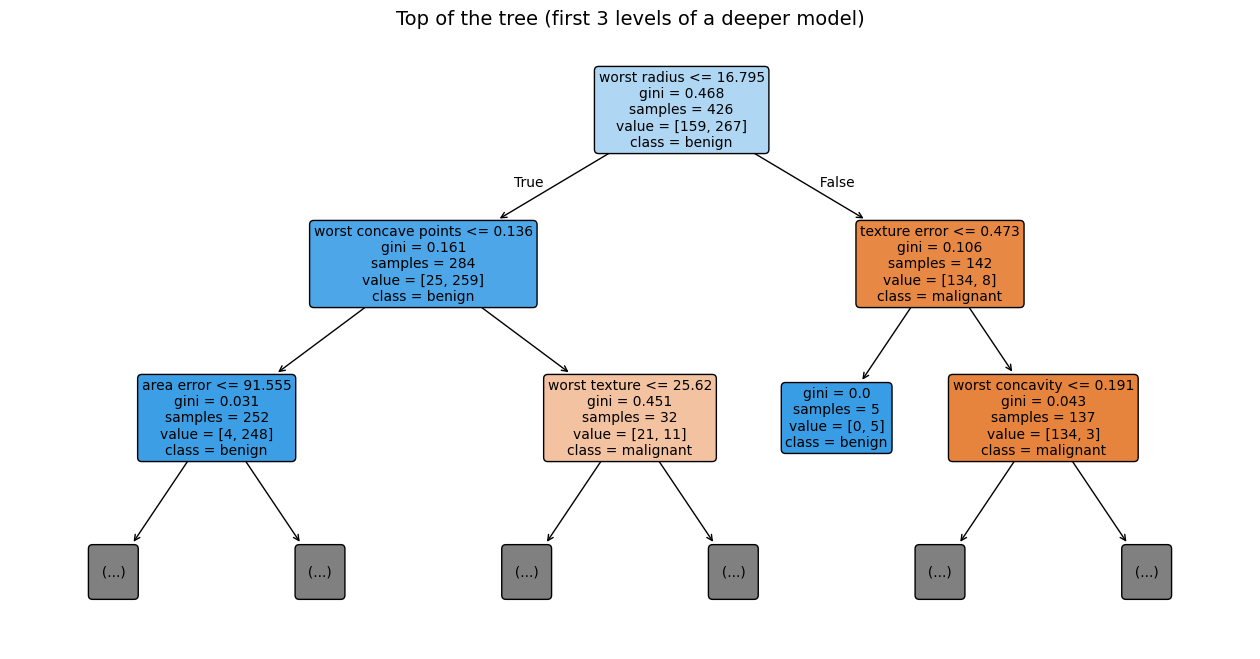

Read a box: the question asked, the Gini impurity, the sample count, the class counts [malignant, benign].


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(full_tree, max_depth=2, feature_names=data.feature_names,
          class_names=data.target_names, filled=True, rounded=True,
          fontsize=10, impurity=True, ax=ax)
plt.title("Top of the tree (first 3 levels of a deeper model)", fontsize=14)
plt.show()
print("Read a box: the question asked, the Gini impurity, the sample count, the class counts [malignant, benign].")

**Read the root box carefully** — you will verify it by hand in a moment. It shows: the question the tree chose to ask first, the node's Gini impurity, how many samples it holds, and the class counts.

Also read one full *path*: root → left → left. Written out, it is a sentence: *"if [root feature] ≤ [threshold] and [next feature] ≤ [threshold], then …"*. That sentence is what interpretability means.

---
## Part 3 · Verify the machine's arithmetic

In Activity 1 you computed weighted Ginis by hand. Now check the machine did the same thing. Everything about a fitted tree lives in `model.tree_` — arrays indexed by node id (root = 0, children via `children_left` / `children_right`).

In [5]:
t = full_tree.tree_

# --- the root's own impurity ---
root_counts = t.value[0][0] * t.weighted_n_node_samples[0] if t.value[0][0].sum() <= 1.001 else t.value[0][0]
root_counts = np.round(root_counts).astype(int)
n_root = root_counts.sum()
p = root_counts / n_root
gini_by_hand = 1 - np.sum(p ** 2)

print(f"root question:      {data.feature_names[t.feature[0]]} <= {t.threshold[0]:.3f}")
print(f"root class counts:  {root_counts}  (n = {n_root})")
print(f"Gini by hand:       1 - ({root_counts[0]}/{n_root})² - ({root_counts[1]}/{n_root})² = {gini_by_hand:.4f}")
print(f"Gini per sklearn:   {t.impurity[0]:.4f}")
print(f"agree: {'✔ YES' if abs(gini_by_hand - t.impurity[0]) < 1e-3 else '✘ check your arithmetic'}")

root question:      worst radius <= 16.795
root class counts:  [159 267]  (n = 426)
Gini by hand:       1 - (159/426)² - (267/426)² = 0.4679
Gini per sklearn:   0.4679
agree: ✔ YES


In [6]:
# --- and the root split's weighted child impurity (the split's score) ---
L, R = t.children_left[0], t.children_right[0]
nL, nR = t.n_node_samples[L], t.n_node_samples[R]
weighted_children = (nL / n_root) * t.impurity[L] + (nR / n_root) * t.impurity[R]

print(f"left child : n={nL:3d}, Gini={t.impurity[L]:.4f}")
print(f"right child: n={nR:3d}, Gini={t.impurity[R]:.4f}")
print(f"weighted child impurity: ({nL}/{n_root})·{t.impurity[L]:.4f} + ({nR}/{n_root})·{t.impurity[R]:.4f} = {weighted_children:.4f}")
print(f"impurity drop achieved by the root split: {t.impurity[0] - weighted_children:.4f}")
print("\nThe machine ran Activity 1's tournament over 30 features × every threshold — this split won.")

left child : n=284, Gini=0.1606
right child: n=142, Gini=0.1063
weighted child impurity: (284/426)·0.1606 + (142/426)·0.1063 = 0.1425
impurity drop achieved by the root split: 0.3254

The machine ran Activity 1's tournament over 30 features × every threshold — this split won.


---
## Part 4 · Tune the depth knob — honestly

The lecture's curve, rebuilt on medical data by you: training vs cross-validation accuracy across `max_depth`. (All on training data — the test set stays locked.)

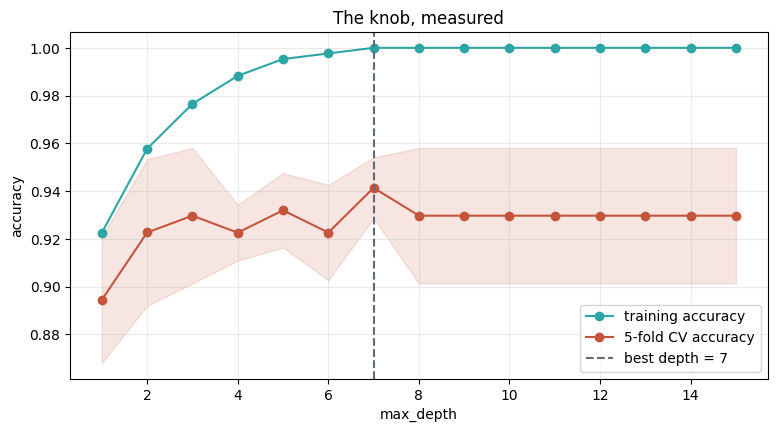

best depth by CV: 7  (0.941 ± 0.013)


In [7]:
depths = range(1, 16)
train_acc, cv_mean, cv_std = [], [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RNG_SEED)
    m.fit(Xtr, ytr)
    train_acc.append(m.score(Xtr, ytr))
    sc = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=RNG_SEED), Xtr, ytr, cv=5)
    cv_mean.append(sc.mean()); cv_std.append(sc.std())

cv_mean, cv_std = np.array(cv_mean), np.array(cv_std)
best_depth = list(depths)[int(cv_mean.argmax())]

plt.figure(figsize=(9, 4.5))
plt.plot(depths, train_acc, marker="o", label="training accuracy", color="#2CA6A4")
plt.plot(depths, cv_mean, marker="o", label="5-fold CV accuracy", color="#C4553B")
plt.fill_between(depths, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15, color="#C4553B")
plt.axvline(best_depth, ls="--", color="#5F6B76", label=f"best depth = {best_depth}")
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend(); plt.grid(alpha=.25)
plt.title("The knob, measured")
plt.show()
print(f"best depth by CV: {best_depth}  ({cv_mean.max():.3f} ± {cv_std[cv_mean.argmax()]:.3f})")

Read it like the lecture taught: training marches toward 1.0; CV rises, then **stops improving**. Whether CV visibly falls or just plateaus, the diagnosis instrument is the same — the *gap*. Also note the shaded band: several depths sit within one standard deviation of the "best" one. Say that honestly when you report.

---
## Part 5 · Post-pruning: the ccp_alpha sweep

The other philosophy — grow fully, then cut. sklearn hands us the exact list of α values worth trying.

12 candidate alphas from 0.00000 to 0.0547


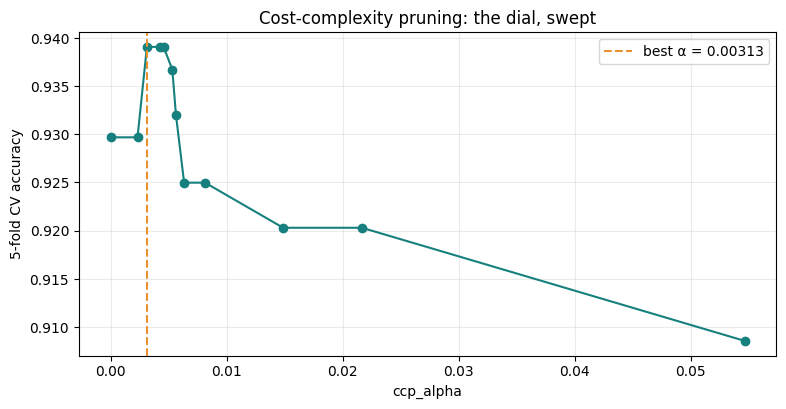

best α = 0.00313 → CV 0.939
tree shrank: 18 leaves → 11 leaves (depth 7 → 5)


In [8]:
path = DecisionTreeClassifier(random_state=RNG_SEED).cost_complexity_pruning_path(Xtr, ytr)
alphas = path.ccp_alphas[:-1]            # drop the last α (prunes to a stump)
print(f"{len(alphas)} candidate alphas from {alphas.min():.5f} to {alphas.max():.4f}")

alpha_cv = []
for a in alphas:
    sc = cross_val_score(DecisionTreeClassifier(random_state=RNG_SEED, ccp_alpha=a), Xtr, ytr, cv=5)
    alpha_cv.append(sc.mean())
alpha_cv = np.array(alpha_cv)
best_alpha = alphas[int(alpha_cv.argmax())]

plt.figure(figsize=(9, 4.2))
plt.plot(alphas, alpha_cv, marker="o", color="#15807E")
plt.axvline(best_alpha, ls="--", color="#E8912D", label=f"best α = {best_alpha:.5f}")
plt.xlabel("ccp_alpha"); plt.ylabel("5-fold CV accuracy"); plt.legend(); plt.grid(alpha=.25)
plt.title("Cost-complexity pruning: the dial, swept")
plt.show()

pruned = DecisionTreeClassifier(random_state=RNG_SEED, ccp_alpha=best_alpha).fit(Xtr, ytr)
print(f"best α = {best_alpha:.5f} → CV {alpha_cv.max():.3f}")
print(f"tree shrank: {full_tree.get_n_leaves()} leaves → {pruned.get_n_leaves()} leaves "
      f"(depth {full_tree.get_depth()} → {pruned.get_depth()})")

One dial, honestly tuned, and the tree got **smaller and no worse** — often slightly better. Smaller also means: easier to read, more stable, faster. Pruning rarely costs anything worth having.

---
## Part 6 · The instability demo

The lecture claimed: change the data slightly, get a visibly different tree. Let's manufacture "slightly": two **bootstrap samples** (draw n rows *with replacement* from the same training data — same size, slightly different composition), one tree each.

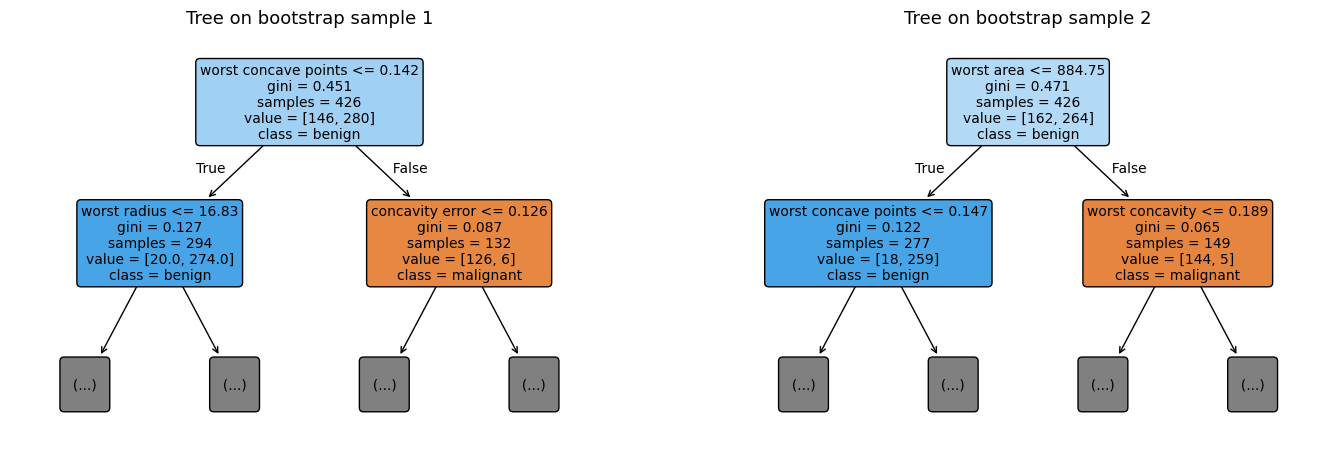

root of tree 1: worst concave points
root of tree 2: worst area
SAME data distribution, SAME algorithm, SAME hyperparameters — different flowchart.


In [9]:
rng = np.random.default_rng(0)
idx1 = rng.choice(len(Xtr), size=len(Xtr), replace=True)
idx2 = rng.choice(len(Xtr), size=len(Xtr), replace=True)

tree1 = DecisionTreeClassifier(max_depth=3, random_state=RNG_SEED).fit(Xtr[idx1], ytr[idx1])
tree2 = DecisionTreeClassifier(max_depth=3, random_state=RNG_SEED).fit(Xtr[idx2], ytr[idx2])

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
for ax, tr, name in [(axes[0], tree1, "Tree on bootstrap sample 1"), (axes[1], tree2, "Tree on bootstrap sample 2")]:
    plot_tree(tr, max_depth=1, feature_names=data.feature_names, class_names=data.target_names,
              filled=True, rounded=True, fontsize=10, ax=ax)
    ax.set_title(name, fontsize=13)
plt.show()

r1 = data.feature_names[tree1.tree_.feature[0]]
r2 = data.feature_names[tree2.tree_.feature[0]]
print(f"root of tree 1: {r1}")
print(f"root of tree 2: {r2}")
print("SAME data distribution, SAME algorithm, SAME hyperparameters — different flowchart." if r1 != r2
      else "This pair happened to agree at the root — inspect the second level, where they diverge.")

**Same distribution. Same algorithm. Same settings.** The only difference is which rows happened to be drawn — and the "explanation" reorganized. Now imagine you'd shown a doctor tree 1's flowchart last month and tree 2's this month.

This is the fact Week 7 is built on: if resampling produces *different* trees, then averaging *many* resampled trees cancels their individual twitchiness. You just built, by hand, two members of a Random Forest.

---
## Part 7 · Feature importance — with its caveats

Which features did the (pruned) tree actually use?

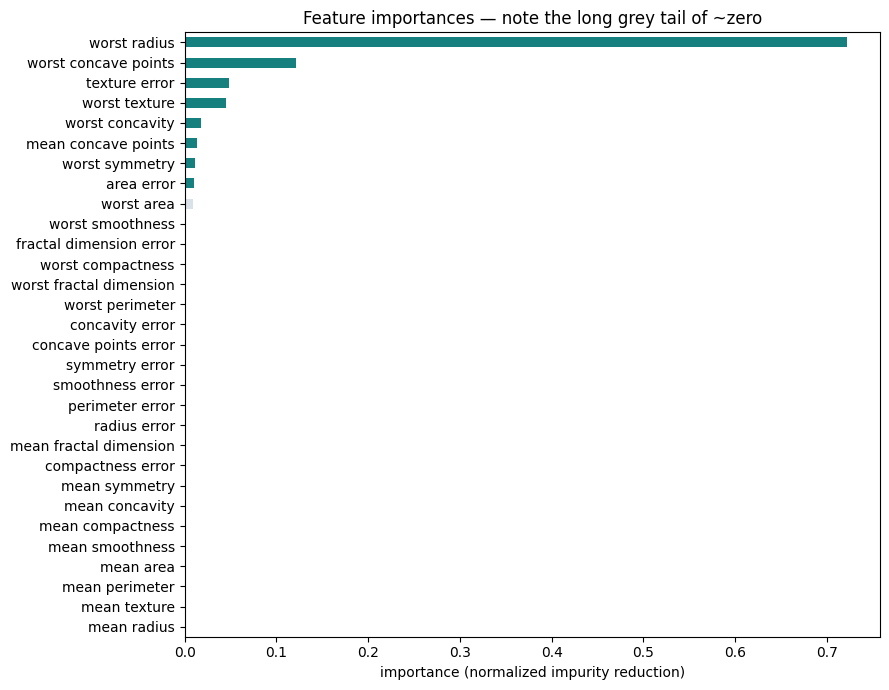

features with importance < 0.01: 22 of 30
top feature: worst radius  (0.722)


In [10]:
imp = pd.Series(pruned.feature_importances_, index=data.feature_names).sort_values()

plt.figure(figsize=(9, 7))
imp.plot.barh(color=["#D9E2E8" if v < 0.01 else "#15807E" for v in imp])
plt.xlabel("importance (normalized impurity reduction)")
plt.title("Feature importances — note the long grey tail of ~zero")
plt.tight_layout(); plt.show()

print(f"features with importance < 0.01: {(imp < 0.01).sum()} of {len(imp)}")
print(f"top feature: {imp.idxmax()}  ({imp.max():.3f})")

Most features score **near zero**. Before concluding they're useless, recall the lecture's two caveats — you'll write them in your own words in Exercise 6's spirit below:

1. **Correlated features split the credit.** These 30 features include radius, perimeter and area of the same nuclei — heavily correlated families. The tree used one representative per family; the siblings show ~0. *Unused ≠ uninformative.*
2. **This ranking belongs to THIS tree** — and Part 6 just showed you how stable "this tree" is.

---
---
# 🏋️ Exercises (graded)

Replace each `...`, run every ✅ self-check, complete the disclosure. Be ready to explain any line orally.

### Exercise 1 — Gini by hand, no library
The full dataset holds 212 malignant and 357 benign samples. Using only NumPy, compute:
- **`gini_dataset`** — the Gini impurity of the whole dataset (before any split)

In [ ]:
counts = np.array([212, 357])
gini_dataset = ...
print(round(gini_dataset, 4))

In [ ]:
# ✅ Self-check — Exercise 1
assert abs(gini_dataset - 0.4675) < 1e-3, "Gini = 1 − Σ pᵢ² with p = counts/total. Expect ≈ 0.4675."
print("Exercise 1 self-check passed ✔  — a 37/63 mix is fairly impure (max would be 0.5).")

### Exercise 2 — A sensibly pruned tree
Build and evaluate (nothing touches the test set):
1. **`tree_pruned`** — a `DecisionTreeClassifier` with `max_depth=4`, `min_samples_leaf=5`, `random_state=RNG_SEED`
2. **`cv_pruned`** — its 5-fold CV scores on the training data
3. **`cv_pruned_mean`** — the mean

In [ ]:
tree_pruned = ...
cv_pruned = ...
cv_pruned_mean = ...
print(cv_pruned.round(3), '| mean:', round(cv_pruned_mean, 3))

In [ ]:
# ✅ Self-check — Exercise 2
pp = tree_pruned.get_params()
assert pp["max_depth"] == 4 and pp["min_samples_leaf"] == 5, "Set max_depth=4 AND min_samples_leaf=5."
assert pp["random_state"] == RNG_SEED, "Set random_state=RNG_SEED for reproducibility."
assert len(cv_pruned) == 5 and cv_pruned_mean > 0.90, "5-fold CV on TRAINING data; a pruned tree here scores > 0.90."
print(f"Exercise 2 self-check passed ✔  (CV mean {cv_pruned_mean:.3f})")

### Exercise 3 — Measure the memorization gap
Quantify the full tree's overfitting, using only training-side numbers:
- **`train_full`** — the unrestricted `full_tree`'s training accuracy
- **`cv_full_mean`** — its 5-fold CV mean (computed in Part 2 as `cv_full`)
- **`gap`** — the difference (train − CV)

In [ ]:
train_full = ...
cv_full_mean = ...
gap = ...
print(f'train {train_full:.3f} | CV {cv_full_mean:.3f} | gap {gap:+.3f}')

In [ ]:
# ✅ Self-check — Exercise 3
assert train_full == 1.0, "The unrestricted tree memorizes: training accuracy is exactly 1.0."
assert 0.02 < gap < 0.20, "The train−CV gap should be a real, moderate number here (~0.05–0.08 typically)."
print(f"Exercise 3 self-check passed ✔  — the gap ({gap:.3f}) IS the overfitting, measured without touching the test set.")

### Exercise 4 — Choose α like a professional
From Part 5's sweep you have `alphas` and `alpha_cv`. Now commit:
- **`chosen_alpha`** — the α with the highest CV mean (as Part 5 computed)
- **`final_model`** — a fresh tree with `ccp_alpha=chosen_alpha`, fitted on the **full training set**
- **`test_acc`** — its accuracy on the test set — **the one and only test-set touch in this lab**

In [ ]:
chosen_alpha = ...
final_model = ...
test_acc = ...
print(f'alpha {chosen_alpha:.5f} | CV {alpha_cv.max():.3f} | TEST {test_acc:.3f}')

In [ ]:
# ✅ Self-check — Exercise 4
assert chosen_alpha > 0, "The best α here is a small positive number — pruning genuinely helps."
assert abs(chosen_alpha - alphas[int(alpha_cv.argmax())]) < 1e-12, "chosen_alpha must be the argmax of YOUR sweep."
assert final_model.get_params()["ccp_alpha"] == chosen_alpha, "final_model must use chosen_alpha."
assert 0.85 < test_acc <= 1.0, "Test accuracy should be in a plausible range (~0.92–0.96 typically)."
print(f"Exercise 4 self-check passed ✔  — workflow: sweep by CV → commit once → test ONCE ({test_acc:.3f}).")
print("Compare test_acc to the CV estimate: close together = your honest protocol worked.")

### Exercise 5 — Quantify the instability
Using Part 6's `tree1` and `tree2` (bootstrap twins):
- **`root1`, `root2`** — the *feature name* each tree asks about at its root
- **`roots_differ`** — boolean: are they different?
- **`top5_overlap`** — how many features appear in BOTH trees' top-5 importance lists (0–5)

In [ ]:
root1 = ...
root2 = ...
roots_differ = ...
top5_1 = ...
top5_2 = ...
top5_overlap = ...
print(root1, '|', root2, '| differ:', roots_differ, '| top-5 overlap:', top5_overlap, '/ 5')

In [ ]:
# ✅ Self-check — Exercise 5
assert root1 == data.feature_names[tree1.tree_.feature[0]], "root1 must come from tree1's actual root node."
assert root2 == data.feature_names[tree2.tree_.feature[0]], "root2 must come from tree2's actual root node."
assert roots_differ == (root1 != root2), "roots_differ must be computed, not typed."
assert isinstance(top5_overlap, int) and 0 <= top5_overlap <= 5, "top5_overlap counts shared members of the two top-5 sets."
_o = len(set(pd.Series(tree1.feature_importances_, index=data.feature_names).nlargest(5).index) &
         set(pd.Series(tree2.feature_importances_, index=data.feature_names).nlargest(5).index))
assert top5_overlap == _o, "Recompute: intersection of the two top-5 importance sets."
print(f"Exercise 5 self-check passed ✔  — same distribution, overlapping evidence, different stories.")
print("This number is worth remembering when someone shows you 'THE' important features of a single tree.")

---
## AI-usage disclosure (required)

> **AI tools used:** *e.g., "Claude — explained the tree_.value array layout; helped debug my Exercise 5 set logic" — or — "None."*
>
> **Written and understood by:** *your name & student ID*

## 📤 Submitting

1. **Runtime → Restart session and run all** — clean run, every self-check *passed*.
2. Disclosure filled, notebook renamed `Lab4_<student_id>`.
3. **File → Download → .ipynb** → upload to the MS  Team.

---
*Dataset: Breast Cancer Wisconsin (Diagnostic), UCI Machine Learning Repository, via scikit-learn.*